In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

plt.style.use("ggplot")

In [2]:
input_dir = "convergence_results_final"
mcmc_main_swd = np.load(os.path.join(input_dir, "swd_obs.npy"))
mcmc_med_swd = np.load(os.path.join(input_dir, "swd_med.npy"))
mcmc_98_swd = np.load(os.path.join(input_dir, "swd_98.npy"))
base_swd = np.load("convergence_results/run_00/base_swd_list.npy")

mcmc_main_avg = np.mean(mcmc_main_swd, axis=0) / base_swd[0]
mcmc_med_avg = np.mean(mcmc_med_swd, axis=0) / base_swd[1]
mcmc_98_avg = np.mean(mcmc_98_swd, axis=0) / base_swd[2]
mcmc_main_std = np.std(mcmc_main_swd / base_swd[0], axis=0)
mcmc_med_std = np.std(mcmc_med_swd / base_swd[1], axis=0)
mcmc_98_std = np.std(mcmc_98_swd / base_swd[2], axis=0)

In [3]:
mala_swd = np.load("convergence_results_mala/rel_swd.npy")
mala_swd

array([0.55963002, 0.55772481, 0.55771386, 0.55449874, 0.55052813,
       0.5436392 , 0.53479717, 0.5243687 , 0.5054698 , 0.47902945,
       0.44779653, 0.41442952, 0.37483863, 0.33643719, 0.31941102,
       0.28086863, 0.27240013, 0.25532573, 0.23448482])

In [4]:
mcmc_main_avg

array([0.50566291, 0.46869994, 0.43719446, 0.41067553, 0.3836239 ,
       0.3540823 , 0.31083459, 0.26584422, 0.21033497, 0.16465147,
       0.11866918, 0.08621849, 0.06461931, 0.04678057, 0.04212414,
       0.03527048, 0.03060742, 0.02754999])

In [5]:
si_input = "convergence_results"
ntrials = 10
nsamps = 23
si_swd = np.empty((ntrials, nsamps, 3))
for i in range(ntrials):
    si_samps = np.load(os.path.join(si_input, f"run_{i:02d}", "rel_swd_array.npy"))
    si_swd[i] = si_samps

si_main = si_swd[:, :, 0]
si_med = si_swd[:, :, 1]
si_98 = si_swd[:, :, 2]
si_main_avg = np.mean(si_main, axis=0)
si_med_avg = np.mean(si_med, axis=0)
si_98_avg = np.mean(si_98, axis=0)
si_main_std = np.std(si_main, axis=0)
si_med_std = np.std(si_med, axis=0)
si_98_std = np.std(si_98, axis=0)

In [6]:
si_main_std

array([0.0650462 , 0.06412232, 0.03073051, 0.05805303, 0.05761845,
       0.0339617 , 0.01397947, 0.03251253, 0.02161245, 0.0203762 ,
       0.00964803, 0.01141382, 0.00798699, 0.0080301 , 0.01194918,
       0.01371797, 0.01546448, 0.01446441, 0.0187306 , 0.01424356,
       0.01264926, 0.01330823, 0.01141601])

In [7]:
sample_no_list = [2 ** i for i in range(1, 15)]          # 2 … 16384
sample_no_list += [20000, 30000, 40000, 50000,
                60000, 70000, 80000, 90000, 100000]
sample_no_list  = sorted(set(sample_no_list))
sample_no_list = np.array(sample_no_list)

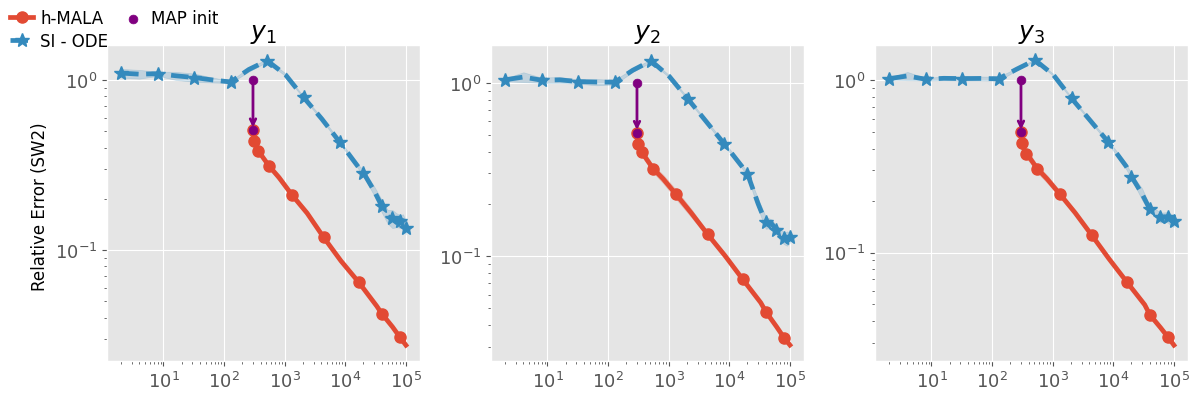

In [17]:
prior_error = 1.0  # error at 2 samples from prior-init chain

# ---- cost conversion ----
si_fme_factor = 1.0
mcmc_step_fme_factor = 2.0  # one h-MALA step ≈ 2 FMEs

sample_no_arr = np.array(sample_no_list)
n_mcmc = len(mcmc_main_avg)  # 18 points (up to 50000 samples)

# SI x-values: one SI sample = 1 FME
si_x = si_fme_factor * sample_no_arr

# h-MALA x-values: training cost + 2 FMEs per chain step
nevals_norm = 300
nevals_mod  = 300
nevals_rare = 300
sample_no_arr_mcmc = sample_no_arr[:n_mcmc]
mcmc_x_norm = nevals_norm + mcmc_step_fme_factor * sample_no_arr_mcmc
mcmc_x_mod  = nevals_mod  + mcmc_step_fme_factor * sample_no_arr_mcmc
mcmc_x_rare = nevals_rare + mcmc_step_fme_factor * sample_no_arr_mcmc

fig, ax = plt.subplots(1, 3, figsize=(12, 4))

# --- norm (y1) ---
im0_1 = ax[0].plot(
    mcmc_x_norm, mcmc_main_avg,
    marker="o", markevery=2, linewidth=3.4, markersize=8, label="h-MALA",
)
im0_2 = ax[0].plot(
    si_x, si_main_avg,
    marker="*", linestyle="dashed", linewidth=3.4, markersize=10.5, markevery=2, label="SI - ODE",
)
ax[0].fill_between(
    mcmc_x_norm,
    mcmc_main_avg - mcmc_main_std,
    mcmc_main_avg + mcmc_main_std,
    color=im0_1[0].get_color(), alpha=0.2,
)
ax[0].fill_between(
    si_x,
    si_main_avg - si_main_std,
    si_main_avg + si_main_std,
    color=im0_2[0].get_color(), alpha=0.2,
)
ax[0].annotate("",
    xy=(nevals_norm, mcmc_main_avg[0]),
    xytext=(nevals_norm, prior_error),
    arrowprops=dict(arrowstyle="->", color="purple", lw=2))
ax[0].scatter([nevals_norm], [prior_error], color="purple", zorder=5, s=40)
ax[0].scatter([nevals_norm], [mcmc_main_avg[0]], color="purple", zorder=5, s=40, label="MAP init")
ax[0].set_xscale("log")
ax[0].set_yscale("log")
ax[0].set_title(r"$y_1$", fontsize=18, pad=4)
ax[0].tick_params(labelsize=13)

# --- mod (y2) ---
im1_1 = ax[1].plot(
    mcmc_x_mod, mcmc_med_avg,
    marker="o", markevery=2, linewidth=3.4, markersize=8,
)
im1_2 = ax[1].plot(
    si_x, si_med_avg,
    marker="*", linestyle="dashed", linewidth=3.4, markersize=10.5, markevery=2,
)
ax[1].fill_between(
    mcmc_x_mod,
    mcmc_med_avg - mcmc_med_std,
    mcmc_med_avg + mcmc_med_std,
    color=im1_1[0].get_color(), alpha=0.2,
)
ax[1].fill_between(
    si_x,
    si_med_avg - si_med_std,
    si_med_avg + si_med_std,
    color=im1_2[0].get_color(), alpha=0.2,
)
ax[1].annotate("",
    xy=(nevals_mod, mcmc_med_avg[0]),
    xytext=(nevals_mod, prior_error),
    arrowprops=dict(arrowstyle="->", color="purple", lw=2))
ax[1].scatter([nevals_mod], [prior_error], color="purple", zorder=5, s=40)
ax[1].scatter([nevals_mod], [mcmc_med_avg[0]], color="purple", zorder=5, s=40)
ax[1].set_xscale("log")
ax[1].set_yscale("log")
ax[1].set_title(r"$y_2$", fontsize=18, pad=4)
ax[1].tick_params(labelsize=13)

# --- rare (y3) ---
im2_1 = ax[2].plot(
    mcmc_x_rare, mcmc_98_avg,
    marker="o", markevery=2, linewidth=3.4, markersize=8,
)
im2_2 = ax[2].plot(
    si_x, si_98_avg,
    marker="*", linestyle="dashed", linewidth=3.4, markersize=10.5, markevery=2,
)
ax[2].fill_between(
    mcmc_x_rare,
    mcmc_98_avg - mcmc_98_std,
    mcmc_98_avg + mcmc_98_std,
    color=im2_1[0].get_color(), alpha=0.2,
)
ax[2].fill_between(
    si_x,
    si_98_avg - si_98_std,
    si_98_avg + si_98_std,
    color=im2_2[0].get_color(), alpha=0.2,
)
ax[2].annotate("",
    xy=(nevals_rare, mcmc_98_avg[0]),
    xytext=(nevals_rare, prior_error),
    arrowprops=dict(arrowstyle="->", color="purple", lw=2))
ax[2].scatter([nevals_rare], [prior_error], color="purple", zorder=5, s=40)
ax[2].scatter([nevals_rare], [mcmc_98_avg[0]], color="purple", zorder=5, s=40)
ax[2].set_xscale("log")
ax[2].set_yscale("log")
ax[2].set_title(r"$y_3$", fontsize=18, pad=4)
ax[2].tick_params(labelsize=13)

fig.supylabel("Relative Error (SW2)")

handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="upper left",
    ncol=2,
    frameon=False,
    fontsize=12,
    handlelength=1.4,
    handletextpad=0.4,
    columnspacing=0.8,
    labelspacing=0.3,
    borderaxespad=0.2,
)

plt.tight_layout()
plt.savefig("images/conv_p_poisson.png", dpi=300, bbox_inches="tight")
plt.show()

In [8]:
mcmc_main_avg

array([0.4190567 , 0.37108776, 0.3190843 , 0.29551042, 0.26339615,
       0.20085859, 0.13931027, 0.10534456, 0.08082771, 0.05867012,
       0.04211468, 0.02858532, 0.0201837 , 0.01327149, 0.01261496,
       0.01098216, 0.00916123, 0.0083761 ])

In [9]:
mcmc_med_avg

array([0.29866975, 0.27343388, 0.24268787, 0.20871855, 0.17144838,
       0.14194002, 0.09981469, 0.07256868, 0.05078228, 0.03559538,
       0.02561426, 0.01856696, 0.01313721, 0.00891261, 0.00838573,
       0.00686079, 0.00605601, 0.00546655])